<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/4_multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy.stats import probplot
from sklearn.datasets import make_regression
import plotly.graph_objects as go

In [45]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

***Feature Engineering***

<Axes: ylabel='Density'>

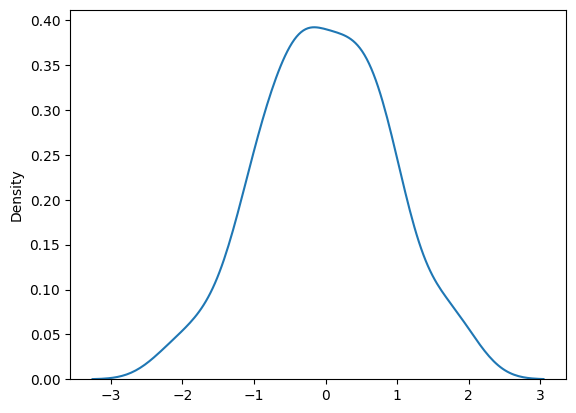

In [46]:
sns.kdeplot(X[:,0])

<Axes: ylabel='Density'>

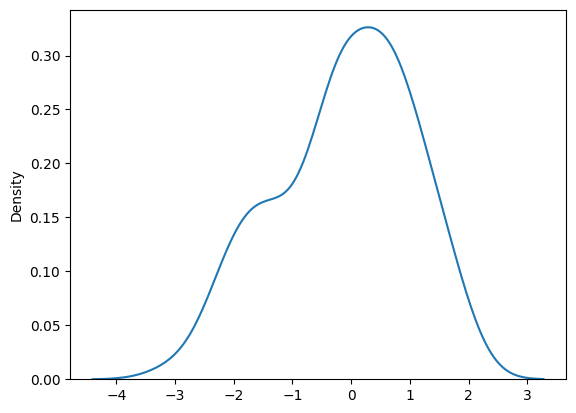

In [47]:
sns.kdeplot(X[:,1])

In [48]:
df=pd.DataFrame(
   {
    "f1": X[:,0],
    "f2": X[:,1],
    "target": y
   }
)

In [49]:
df.head()

,f1,f2,target
0,-0.638198,0.539750,-20.385785
1,-0.543420,0.187029,17.476424
2,1.977486,-0.542173,199.664550
3,-0.469346,1.759694,162.720779
4,0.804532,1.057175,177.260319


In [50]:
df["f2"].skew()

np.float64(-0.3999267417459311)

In [51]:
fig=px.scatter_3d(df,x="f1",y="f2", z="target")
fig.show()

**Alogorithm Muliple Regression**

In [52]:
X_train, X_test, y_train ,y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [53]:
lr=LinearRegression()

In [54]:
lr.fit(X_train, y_train)

LinearRegression()

In [55]:
y_pred=lr.predict(X_test)

In [56]:
lr.coef_

array([87.78694268, 53.43432539])

In [57]:
lr.intercept_

np.float64(0.5365323919049692)

In [58]:
print("MSE", mean_squared_error(y_test, y_pred))
print("R2 Score", r2_score(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))

MSE 2243.448637527616
R2 Score 0.804456806395526
MAE 37.132099304547594


In [59]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((
 xGrid.ravel().reshape(1, 100),
 yGrid.ravel().reshape(1, 100)
))

final=final.T


In [60]:
z_final = lr.predict(final).reshape(10,10)

z = z_final

In [61]:
fig = px.scatter_3d(df, x='f1', y='f2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()